In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# Load datasets
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data - historical_data.csv")


In [24]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [25]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [23]:
def dataset_summary(df, name):
    print(f"\n{name}")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("Missing values:", df.isna().sum().sum())
    print("Duplicates:", df.duplicated().sum())

dataset_summary(sentiment, "Sentiment Dataset")
dataset_summary(trades, "Trades Dataset")


Sentiment Dataset
Rows: 2644
Columns: 4
Missing values: 0
Duplicates: 0

Trades Dataset
Rows: 211224
Columns: 16
Missing values: 0
Duplicates: 0


In [28]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [29]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [5]:
# Sentiment dates
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

# Trade timestamps are epoch seconds
trades["Timestamp"] = pd.to_datetime(trades["Timestamp"])
trades["date"] = trades["Timestamp"].dt.date


In [6]:
df = trades.merge(
    sentiment[["date", "classification"]],
    on="date",
    how="inner"
)

In [7]:
df = df.rename(columns={
    "Account": "account",
    "Coin": "symbol",
    "Side": "side",
    "Size USD": "size_usd",
    "Closed PnL": "closed_pnl"
})

In [8]:
df["win"] = df["closed_pnl"] > 0
df["is_long"] = df["side"].str.lower().isin(["buy", "long"])

In [9]:
daily_metrics = (
    df.groupby(["date", "classification", "account"])
      .agg(
          daily_pnl=("closed_pnl", "sum"),
          win_rate=("win", "mean"),
          avg_trade_size=("size_usd", "mean"),
          trades_per_day=("symbol", "count"),
          long_ratio=("is_long", "mean")
      )
      .reset_index()
)

In [10]:
sentiment_perf = (
    daily_metrics.groupby("classification")
    .agg(
        avg_daily_pnl=("daily_pnl", "mean"),
        avg_win_rate=("win_rate", "mean"),
        avg_trades=("trades_per_day", "mean"),
        avg_trade_size=("avg_trade_size", "mean"),
        avg_long_ratio=("long_ratio", "mean")
    )
    .reset_index()
)

print(sentiment_perf)

Empty DataFrame
Columns: [classification, avg_daily_pnl, avg_win_rate, avg_trades, avg_trade_size, avg_long_ratio]
Index: []


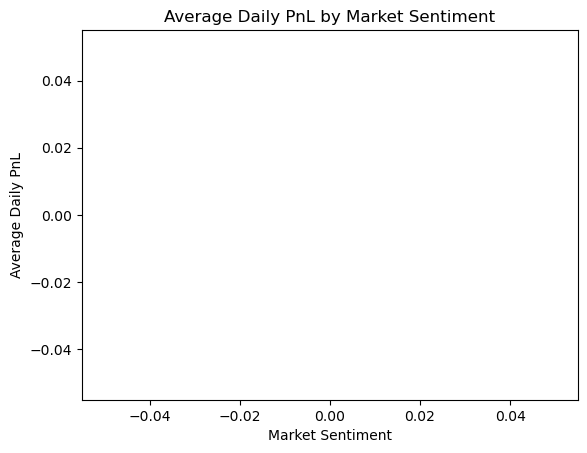

In [11]:
plt.figure()
plt.bar(sentiment_perf["classification"], sentiment_perf["avg_daily_pnl"])
plt.title("Average Daily PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Daily PnL")
plt.show()

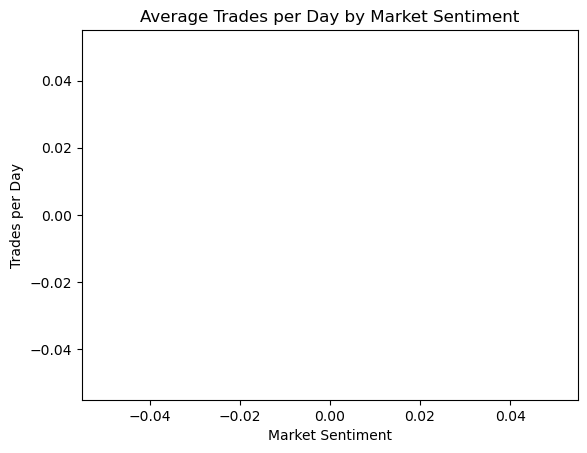

In [12]:
plt.figure()
plt.bar(sentiment_perf["classification"], sentiment_perf["avg_trades"])
plt.title("Average Trades per Day by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trades per Day")
plt.show()

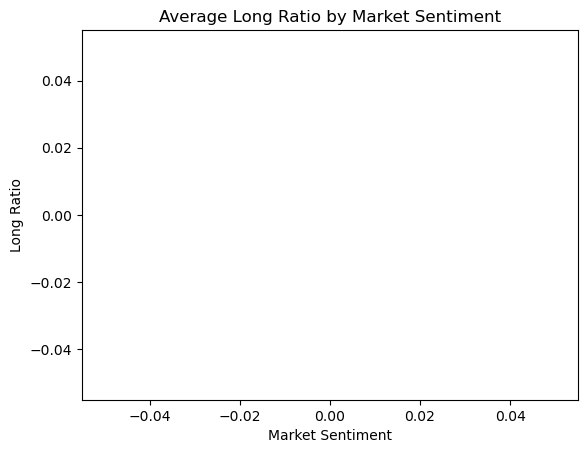

In [13]:
plt.figure()
plt.bar(sentiment_perf["classification"], sentiment_perf["avg_long_ratio"])
plt.title("Average Long Ratio by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Long Ratio")
plt.show()

In [14]:
daily_metrics["activity_segment"] = np.where(
    daily_metrics["trades_per_day"] >= daily_metrics["trades_per_day"].median(),
    "Frequent",
    "Infrequent"
)

segment_perf = (
    daily_metrics.groupby(["classification", "activity_segment"])
    .agg(
        avg_pnl=("daily_pnl", "mean"),
        win_rate=("win_rate", "mean")
    )
    .reset_index()
)

print(segment_perf)

Empty DataFrame
Columns: [classification, activity_segment, avg_pnl, win_rate]
Index: []


In [15]:
trader_consistency = (
    daily_metrics.groupby("account")
    .agg(
        avg_win_rate=("win_rate", "mean"),
        pnl_volatility=("daily_pnl", "std")
    )
    .reset_index()
)

threshold = trader_consistency["avg_win_rate"].median()

trader_consistency["consistency_segment"] = np.where(
    trader_consistency["avg_win_rate"] >= threshold,
    "Consistent Winners",
    "Inconsistent Traders"
)

In [16]:
fear_days = daily_metrics[daily_metrics["classification"].str.contains("Fear")]

fear_summary = fear_days.groupby("activity_segment").agg(
    avg_pnl=("daily_pnl", "mean"),
    avg_trades=("trades_per_day", "mean")
)

print(fear_summary)

Empty DataFrame
Columns: [avg_pnl, avg_trades]
Index: []


In [17]:
greed_days = daily_metrics[daily_metrics["classification"].str.contains("Greed")]

greed_summary = greed_days.groupby("activity_segment").agg(
    avg_pnl=("daily_pnl", "mean"),
    win_rate=("win_rate", "mean")
)

print(greed_summary)

Empty DataFrame
Columns: [avg_pnl, win_rate]
Index: []
